# Distance Models (KNN)

In our previous lessons, we explored algorithms that rely on Optimization and Calculus (Gradient Descent) to learn a global mathematical equation ($\theta^T x$). Once those algorithms learn the parameters, they discard the original dataset; the equation itself makes the predictions.

**K-Nearest Neighbors (KNN)** is fundamentally different. It uses no calculus, learns no global parameters, and has no optimization engine. It is a **"Lazy Learner."** Instead of learning an equation, it memorizes the entire training dataset. When asked to make a prediction, it relies purely on Geometry and Linear Algebra to find the most mathematically similar historical examples.

KNN is a non-parametric algorithm used for both Classification and Regression. It operates on a beautifully simple premise: *Similar data points exist in close proximity to each other.* 

To prove this, we must define exactly what "proximity" means in a high-dimensional feature matrix. Let's set up our Python environment.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import ListedColormap

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Geometric Modeling Environment Ready.")

✅ Geometric Modeling Environment Ready.


# 1. The Mathematics of Distance

Because KNN does not have a Cost Function or Gradient Descent, its entire intelligence is derived from the **Distance Metric**. 

To calculate how similar a new customer ($q$) is to a historical customer ($p$), we represent both customers as vectors in our Feature Space and calculate the distance between them. 

### Euclidean Distance ($L_2$ Norm)
The industry standard is Euclidean distance—the straight-line distance between two points. For a dataset with $n$ features, the distance $d$ between vector $p$ and vector $q$ is defined using the Pythagorean theorem extended to $n$-dimensions:
$$d(p, q) = \sqrt{\sum_{i=1}^{n} (p_i - q_i)^2}$$

### Manhattan Distance ($L_1$ Norm)
If your data features are strictly grid-like (e.g., physical city blocks, or highly distinct categorical dummy variables), computing the absolute differences rather than squaring them often yields better results:
$$d(p, q) = \sum_{i=1}^{n} |p_i - q_i|$$

*The Algorithm:* When a new data point arrives, KNN calculates the distance between this new point and *every single point* in the historical database. It then sorts those distances, selects the $K$ closest points, and takes a majority vote (for classification) or an average (for regression).

# 2. Visualizing Distance and Decision Boundaries

Let's simulate an enterprise scenario: predicting whether a user will subscribe to a **Premium Tier ($1$)** or remain on the **Standard Tier ($0$)** based on their **Platform Engagement** ($X_1$) and **Content Consumed** ($X_2$).

We will train a KNN model and map its Decision Boundary by testing every possible pixel on the screen.

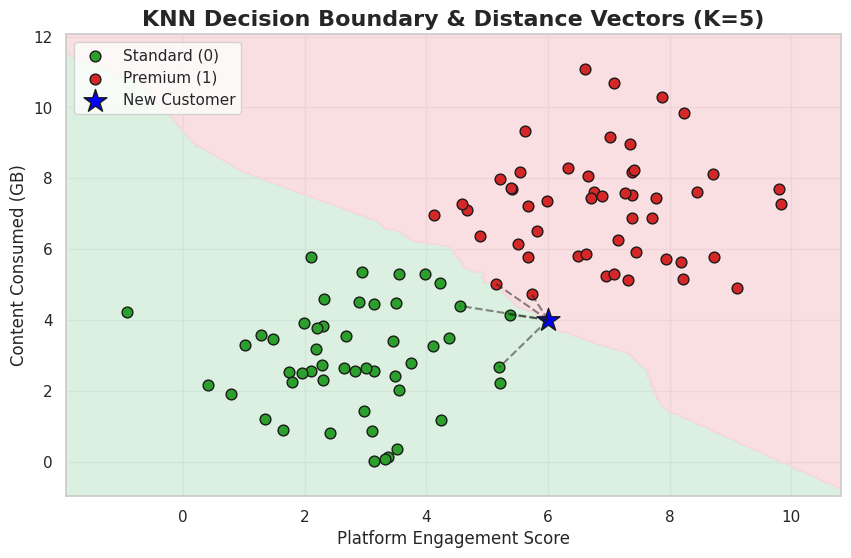

In [2]:
# 1. Simulate Corporate Customer Data
np.random.seed(42)
# Generate Standard Users (centered lower-left)
X_standard = np.random.normal(loc=[3, 3], scale=1.5, size=(50, 2))
y_standard = np.zeros(50)

# Generate Premium Users (centered upper-right)
X_premium = np.random.normal(loc=[7, 7], scale=1.5, size=(50, 2))
y_premium = np.ones(50)

# Combine into Feature Matrix (X) and Target Vector (y)
X = np.vstack((X_standard, X_premium))
y = np.hstack((y_standard, y_premium))

# 2. Train the KNN Model (K=5)
# Note: "Training" in KNN just means storing the data in a fast spatial tree (KD-Tree/Ball Tree)
k_neighbors = 5
knn = KNeighborsClassifier(n_neighbors=k_neighbors, metric='euclidean')
knn.fit(X, y)

# 3. Create a Meshgrid to visualize the Decision Boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

# Predict every point on the grid
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 4. Matplotlib Visualization
plt.figure(figsize=(10, 6))
cmap_light = ListedColormap(['#d4edda', '#f8d7da'])
cmap_bold = ['#2ca02c', '#d62728']

# Plot the decision boundary background
plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)

# Plot the historical data points
plt.scatter(X[y==0][:, 0], X[y==0][:, 1], color=cmap_bold[0], label='Standard (0)', edgecolor='k', s=60)
plt.scatter(X[y==1][:, 0], X[y==1][:, 1], color=cmap_bold[1], label='Premium (1)', edgecolor='k', s=60)

# Simulate a NEW customer and draw lines to their 5 Nearest Neighbors
new_customer = np.array([[6, 4]])
distances, indices = knn.kneighbors(new_customer)
plt.scatter(new_customer[:,0], new_customer[:,1], color='blue', marker='*', s=300, label='New Customer', edgecolor='k')

for neighbor_idx in indices[0]:
    neighbor = X[neighbor_idx]
    plt.plot([new_customer[0,0], neighbor[0]], [new_customer[0,1], neighbor[1]], 'k--', alpha=0.5)

plt.title(f"KNN Decision Boundary & Distance Vectors (K={k_neighbors})", fontsize=16, fontweight='bold')
plt.xlabel("Platform Engagement Score")
plt.ylabel("Content Consumed (GB)")
plt.legend(loc='upper left')
plt.show()

*(Insight: Look at the blue star. The algorithm calculated the exact geometric distance to every single dot on the screen. It isolated the 5 closest points (connected by dashed lines). Because 3 of those neighbors are Premium (red) and 2 are Standard (green), the algorithm predicts Premium via majority vote. Notice how the decision boundary naturally wraps around pockets of data, unlike the rigid straight line of Logistic Regression!)*

# 3. The Hyperparameter $K$ (Bias-Variance Tradeoff)

The number of neighbors ($K$) is a **Hyperparameter**. You, the Data Scientist, must choose it before the algorithm runs. It fundamentally alters the geometry of your model.

*   **If $K = 1$**: The model perfectly memorizes the training data. The decision boundary becomes incredibly jagged, drawing tiny islands around every single outlier. This is **Low Bias, High Variance (Overfitting)**.
*   **If $K = \text{Large}$ (e.g., 50)**: The model looks at a massive radius. Outliers are ignored, and the boundary becomes extremely smooth. If $K$ equals the total number of rows in the dataset, the model simply defaults to the statistical baseline (always guessing the majority class). This is **High Bias, Low Variance (Underfitting)**.

*(Best Practice: Always set $K$ to an odd number when doing binary classification to mathematically prevent a 50/50 tie in the voting process).*

# 4. The Curse of Dimensionality & Feature Scaling

There are two fatal mathematical traps when using Distance Models in enterprise environments:

### Trap 1: Unscaled Features
Imagine our features are `Age` (spanning 18 to 65) and `Annual Salary` (spanning $30,000 to $250,000). 
If we calculate the Euclidean distance, the math is: $$(30,000 - 45,000)^2 + (22 - 35)^2$$

The `Salary` difference is so mathematically massive that it completely annihilates the `Age` difference. The algorithm will act as if `Age` doesn't exist.

**Rule: You MUST mathematically scale your Feature Matrix ($X$) before using KNN.**
We use **Z-Score Standardization** to force every feature to have a Mean of 0 and a Standard Deviation of 1:
$$z = \frac{x - \mu}{\sigma}$$

In [3]:
# The proper way to prepare data for KNN
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("🚨 Data Scaled Successfully. Euclidean distances will now weight all features equally.")

🚨 Data Scaled Successfully. Euclidean distances will now weight all features equally.


### Trap 2: The Curse of Dimensionality
As you add more features (dimensions) to your dataset, the volume of the mathematical space grows exponentially. In a 500-dimensional space, the concept of "distance" breaks down. The distance to the nearest neighbor approaches the distance to the farthest neighbor, making the algorithm essentially guess at random. KNN is highly dangerous on wide datasets (like NLP text vectors).

---

## Real-World Use Case or Analogy:
Think of K-Nearest Neighbors like **Appraising a House in Real Estate**:

*   **No Global Equation**: A real estate agent does not use a rigid mathematical formula (Linear Regression) to price a house. They do not say, *"Every house is worth exactly $50,000 plus $100 per square foot."*
*   **The Distance Metric**: Instead, they look at "Comps" (Comparables). They find historical houses that are *geometrically and feature-wise similar* (same neighborhood, similar square footage, similar age). 
*   **The $K$ Value**: They look at the recent sale prices of the $K=3$ most similar houses, average them together, and assign that price to your house. 
*   **The Scaling Problem**: If they don't "scale" their mental model, they might think a house with 3,000 square feet and 1 bathroom is similar to a house with 3,000 square feet and 4 bathrooms, just because the square footage number is bigger.

---